[Batch GD] Test RMSE = 4.4105
[sklearn LR] Test RMSE = 4.4105
Difference (GD - sklearn) = 0.000000
[Mini-batch GD] Test RMSE = 4.4190


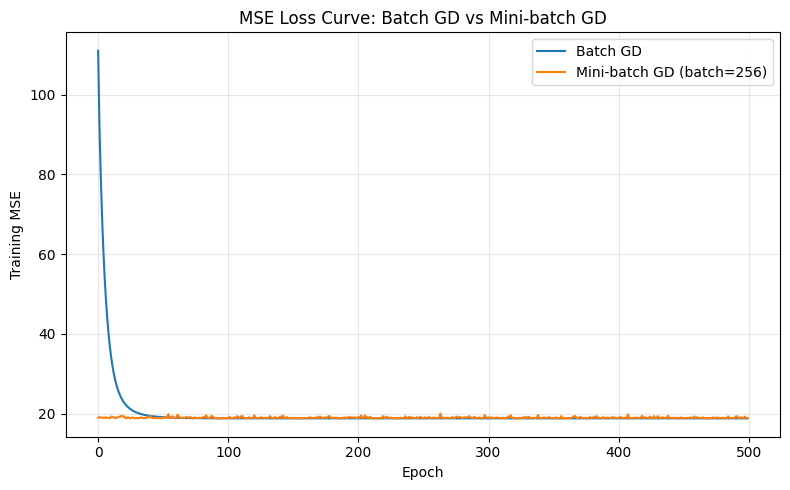


=== RMSE Comparison ===
Method                 Test RMSE
Batch GD                  4.4105
Mini-batch GD             4.4190
sklearn LinearReg         4.4105


In [2]:
# ============================================================
# EXPERIMENT 3
# Batch & Mini-Batch Gradient Descent vs sklearn
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("placement_predict_50k Dataset.csv")

FEATURES = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

TARGET = "Salary Package"


# Select required columns
data = df[FEATURES + [TARGET]].copy()


# Fill missing feature values with median
data[FEATURES] = data[FEATURES].fillna(
    data[FEATURES].median()
)


# Convert to NumPy arrays
X = data[FEATURES].values

y = data[TARGET].values.reshape(-1, 1)


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ============================================================
# 3. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)


# ============================================================
# ADD BIAS / INTERCEPT COLUMN
# ============================================================

n_samples, n_features = X_train_s.shape

X_train_b = np.hstack(
    [
        np.ones((n_samples, 1)),
        X_train_s
    ]
)

X_test_b = np.hstack(
    [
        np.ones((X_test_s.shape[0], 1)),
        X_test_s
    ]
)


# ============================================================
# 4. COMPUTE MSE
# ============================================================

def compute_mse(X, y, theta):

    predictions = X @ theta

    errors = predictions - y

    return np.mean(errors ** 2)


# ============================================================
# 5. BATCH GRADIENT DESCENT
# ============================================================

def batch_gradient_descent(
    X,
    y,
    lr=0.05,
    n_epochs=500
):

    m, n = X.shape

    # Initialize weights
    theta = np.zeros((n, 1))

    # Store loss
    loss_history = []

    # Training loop
    for epoch in range(n_epochs):

        # Predictions
        predictions = X @ theta

        # Error
        errors = predictions - y

        # Gradient
        gradient = (
            2 / m
        ) * (
            X.T @ errors
        )

        # Update weights
        theta -= lr * gradient

        # Store loss
        loss_history.append(
            compute_mse(
                X,
                y,
                theta
            )
        )

    return theta, loss_history


# ============================================================
# TRAIN BATCH GD
# ============================================================

theta_gd, loss_history_gd = batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.05,
    n_epochs=500
)


# ============================================================
# BATCH GD TEST RMSE
# ============================================================

rmse_gd = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_gd
    )
)

print(
    f"[Batch GD] Test RMSE = {rmse_gd:.4f}"
)


# ============================================================
# 6. SKLEARN LINEAR REGRESSION
# ============================================================

sk_model = LinearRegression()

sk_model.fit(
    X_train_s,
    y_train
)


# Predictions
y_pred_sk = sk_model.predict(
    X_test_s
)


# RMSE
rmse_sklearn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_sk
    )
)


print(
    f"[sklearn LR] Test RMSE = {rmse_sklearn:.4f}"
)


# Difference
print(
    f"Difference (GD - sklearn) = "
    f"{rmse_gd - rmse_sklearn:.6f}"
)


# ============================================================
# 7. MINI-BATCH GRADIENT DESCENT
# ============================================================

def mini_batch_gradient_descent(
    X,
    y,
    lr=0.05,
    n_epochs=500,
    batch_size=256,
    seed=42
):

    m, n = X.shape

    # Initialize weights
    theta = np.zeros((n, 1))

    # Store loss
    loss_history = []

    # Random generator
    rng = np.random.default_rng(seed)

    # Epoch loop
    for epoch in range(n_epochs):

        # Shuffle data
        indices = rng.permutation(m)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Process mini-batches
        for start in range(
            0,
            m,
            batch_size
        ):

            end = min(
                start + batch_size,
                m
            )

            X_batch = X_shuffled[start:end]

            y_batch = y_shuffled[start:end]

            # --------------------------------------------
            # Predictions
            # --------------------------------------------

            predictions = X_batch @ theta

            # --------------------------------------------
            # Error
            # --------------------------------------------

            errors = predictions - y_batch

            # --------------------------------------------
            # Gradient
            # --------------------------------------------

            gradient = (
                2 / X_batch.shape[0]
            ) * (
                X_batch.T @ errors
            )

            # --------------------------------------------
            # Update weights
            # --------------------------------------------

            theta -= lr * gradient

        # --------------------------------------------
        # Full training loss
        # --------------------------------------------

        loss_history.append(
            compute_mse(
                X,
                y,
                theta
            )
        )

    return theta, loss_history


# ============================================================
# TRAIN MINI-BATCH GD
# ============================================================

theta_mb, loss_history_mb = mini_batch_gradient_descent(
    X_train_b,
    y_train,
    lr=0.05,
    n_epochs=500,
    batch_size=256,
    seed=42
)


# ============================================================
# MINI-BATCH GD TEST RMSE
# ============================================================

rmse_mb = np.sqrt(
    compute_mse(
        X_test_b,
        y_test,
        theta_mb
    )
)


print(
    f"[Mini-batch GD] Test RMSE = {rmse_mb:.4f}"
)


# ============================================================
# 8. PLOT LOSS CURVES
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    loss_history_gd,
    label="Batch GD"
)

plt.plot(
    loss_history_mb,
    label="Mini-batch GD (batch=256)"
)

plt.xlabel("Epoch")

plt.ylabel("Training MSE")

plt.title(
    "MSE Loss Curve: Batch GD vs Mini-batch GD"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


# Save graph
plt.savefig(
    "loss_curve.png",
    dpi=150
)

plt.show()


# ============================================================
# 9. FINAL RMSE COMPARISON
# ============================================================

print("\n=== RMSE Comparison ===")

print(
    f"{'Method':<20}"
    f"{'Test RMSE':>12}"
)

print(
    f"{'Batch GD':<20}"
    f"{rmse_gd:>12.4f}"
)

print(
    f"{'Mini-batch GD':<20}"
    f"{rmse_mb:>12.4f}"
)

print(
    f"{'sklearn LinearReg':<20}"
    f"{rmse_sklearn:>12.4f}"
)